In [1]:
import numpy as np 
import esam
from FDMT_tests import simulate_narrow_frb as snf
from pylab import *

%matplotlib inline

# do automatic reloading
%load_ext autoreload
%autoreload 2


In [2]:
pwd

'/Users/ban115/bolton/craft/ESAM/esam'

In [3]:
ls -lrth ../*.npy

zsh:1: no matches found: ../*.npy


In [4]:
tree = np.load('../test_data/final_optimised_esam_tree_fast_with_traces_0_1000_0.2_nch256_threshold_0.85.pkl.npy', allow_pickle=True)
# unwrap from nd array
tree = tree.item()

In [5]:
prod_last = tree._products[-1]

In [6]:
prod_last.offset

-142

255.99994 1.0 (np.int64(1), np.int64(104))


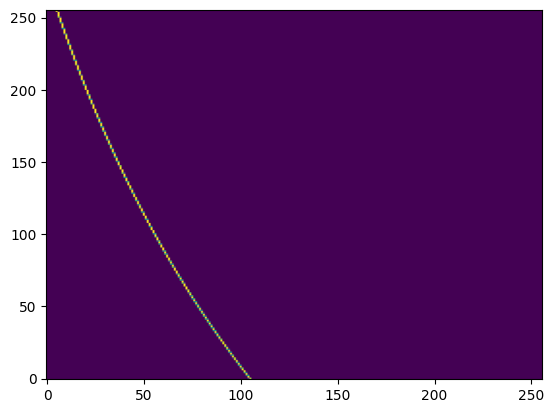

In [7]:
nch = 256
fchans = np.linspace(800.5, 1055.5, nch, endpoint=True, dtype=np.float32)
tx = 100
nsamps = 256
nch = 256
tx = 1
dm = 100
chw_2 = 0.5 # channel width
tpulse = dm + 5.5 # start time
#tpulse = 10
din, ndd = snf.make_pure_frb(nsamps, nch, tx, dm, fchans, chw_2, tpulse)
assert(not np.all(din == 0))
imshow(din, aspect='auto', origin='lower')
print(sum(din), din.max(), np.unravel_index(np.argmax(din), din.shape))

In [8]:
sum(din)
# should be equal to nchan = 256


np.float32(255.99994)

53096


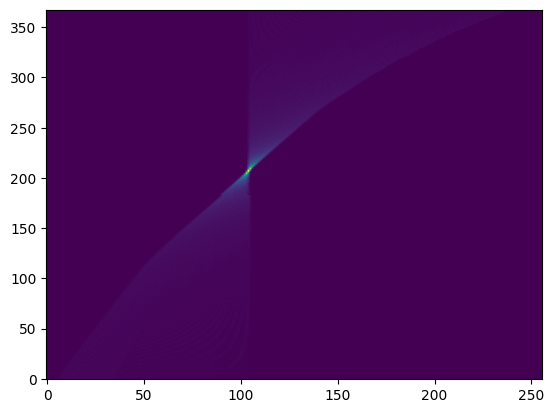

In [9]:
dout = tree(din)
figure()
imshow(dout[:,:], aspect='auto', origin='lower')
print(dout.argmax())


# Check that ESAM of a subband is the same as ESAM of the full band but with outside zeroed

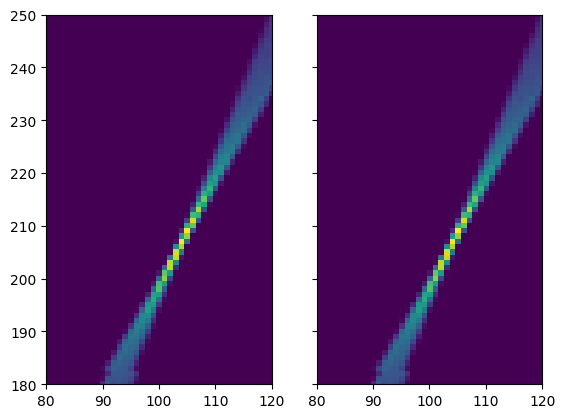

In [10]:
start_chan = 129
end_chan = start_chan + 100
nch = end_chan - start_chan + 1
d2 = np.zeros_like(din)
d2[start_chan:end_chan+1,:] = din[start_chan:end_chan+1,:]
fig, ax = subplots(1,2, sharex=True, sharey=True)
dout1 = tree(d2)
dout2 = tree(din, lower_chan=start_chan, upper_chan=end_chan)
ax[1].imshow(dout1, aspect='auto', origin='lower')
ax[0].imshow(dout2, aspect='auto', origin='lower')
ax[0].set_xlim(80, 120)
ax[1].set_ylim(180,250)
np.testing.assert_allclose(dout1, dout2)


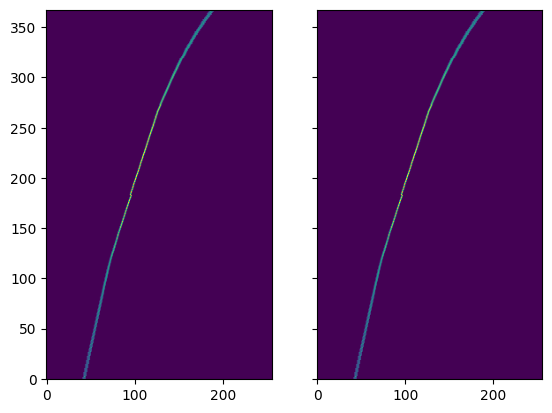

In [11]:
start_chan = 129
end_chan = start_chan + 8
nch = end_chan - start_chan + 1
d2 = np.zeros_like(din)
d2[start_chan:end_chan+1,:] = din[start_chan:end_chan+1,:]
fig, ax = subplots(1,2, sharex=True, sharey=True)
dout1 = tree(d2)
dout2 = tree(din, lower_chan=start_chan, upper_chan=end_chan)
ax[1].imshow(dout1, aspect='auto', origin='lower')
ax[0].imshow(dout2, aspect='auto', origin='lower')
#ax[0].set_xlim(80, 120)
#ax[1].set_ylim(180,250)
np.testing.assert_allclose(dout1, dout2)

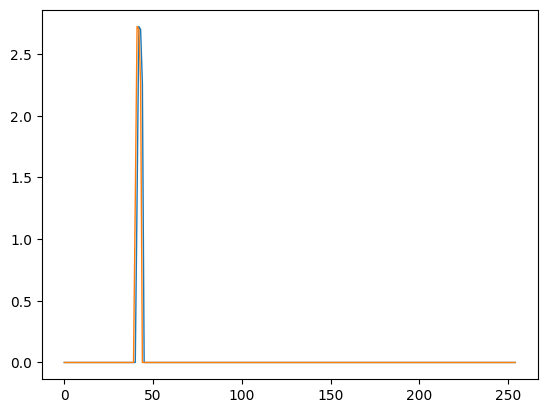

In [12]:
plot(dout1[0, :-1])
plot(dout1[1, 1:])


In [13]:
dout1.shape


(368, 256)

In [14]:
# how much of the output is a shfited version of the next one?
similar = 0
for i in range(dout1.shape[0]-1):
    nexti = i+1
    n = dout.shape[1]
    for offset in range(50):
        #print(dout1[i,:-offset].shape, dout1[nexti, offset:].shape)
        if np.allclose(dout2[i,:n-offset], dout2[nexti, offset:n], atol=1e-2):
            print(f'{i} and {nexti} are offset {offset} close')
            similar += 1

print(f'{similar} out of {dout1.shape[1]-1} are close')


0 and 1 are offset 0 close
3 and 4 are offset 0 close
4 and 5 are offset 0 close
5 and 6 are offset 0 close
6 and 7 are offset 1 close
7 and 8 are offset 0 close
8 and 9 are offset 0 close
9 and 10 are offset 0 close
10 and 11 are offset 1 close
11 and 12 are offset 0 close
12 and 13 are offset 0 close
13 and 14 are offset 0 close
14 and 15 are offset 1 close
15 and 16 are offset 0 close
16 and 17 are offset 0 close
17 and 18 are offset 0 close
20 and 21 are offset 0 close
24 and 25 are offset 0 close
28 and 29 are offset 0 close
32 and 33 are offset 0 close
36 and 37 are offset 0 close
40 and 41 are offset 0 close
44 and 45 are offset 0 close
48 and 49 are offset 0 close
320 and 321 are offset 1 close
337 and 338 are offset 1 close
349 and 350 are offset 1 close
351 and 352 are offset 1 close
363 and 364 are offset 1 close
29 out of 255 are close


In [ ]:
similar = 0
for i in range(dout2.shape[1]-1):
    nexti = i+1
    n = dout.shape[0]
    for offset in range(50):
        #print(dout1[i,:-offset].shape, dout1[nexti, offset:].shape)
        if np.allclose(dout2.T[i,:n-offset], dout2.T[nexti, offset:n], atol=1e-2):
            print(f'{i} and {nexti} are offset {offset} close')
            similar += 1

print(f'{similar} out of {dout1.shape[1]-1} are close')


In [15]:
%timeit dout = tree(din)

11.9 ms ± 332 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [16]:
%timeit dout2 = tree(din, lower_chan=start_chan, upper_chan=start_chan+15)


1.48 ms ± 21.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [17]:
# I have 435 baselines x 288 channels and I'm goign to average 16 channels.
# And finish in 435 ms (256x1.7ms)
required_speed_m = 256*1.7/(432*288/16)
print(f'Required speed is {required_speed_m} ms')



Required speed is 0.05596707818930041 ms


In [18]:
start_chan

129

In [19]:
'''

This is broken. Not sure why.

dout2 = tree(din, lower_chan=start_chan, upper_chan=start_chan+16, pad_with_zeros=False)
dout3 = tree(din, lower_chan=start_chan, upper_chan=start_chan+16, pad_with_zeros=True)
fig,ax = subplots(1,2, sharex=True, sharey=True)
ax[0].imshow(dout2, aspect='auto', origin='lower')
ax[1].imshow(dout3, aspect='auto', origin='lower')

print(dout2.shape, dout3.shape)
'''

"\n\nThis is broken. Not sure why.\n\ndout2 = tree(din, lower_chan=start_chan, upper_chan=start_chan+16, pad_with_zeros=False)\ndout3 = tree(din, lower_chan=start_chan, upper_chan=start_chan+16, pad_with_zeros=True)\nfig,ax = subplots(1,2, sharex=True, sharey=True)\nax[0].imshow(dout2, aspect='auto', origin='lower')\nax[1].imshow(dout3, aspect='auto', origin='lower')\n\nprint(dout2.shape, dout3.shape)\n"

In [20]:
ser = esam.OffsetSeries(np.array([1,2,3,4]), offset=-2)
str(ser)



'Offset=-2 [0 0 1 2]'

In [21]:
ser = esam.OffsetSeries(np.array([1,2,3,4]), offset=2)
print(str(ser), ser[0], ser[1], ser[0:2])



Offset=2 [3 4 0 0] 3 4 [3 4]


## Profiling EsamTree.__call__

### Quick Summary:
1. **Line-by-line profiling (most detailed)**: Use `line_profiler` with `%lprun` magic in Jupyter
2. **Function-level profiling**: Use built-in `cProfile` with `%prun` magic
3. **Standalone script**: See `profile_esam.py` for regular Python profiling

### Install line_profiler for line-by-line profiling:
```bash
pip install line_profiler
```


In [22]:
# Function-level profiling - shows time per function call
# This is built-in to Python, no extra packages needed
%prun for i in range(1000): dout = tree(din, lower_chan=start_chan, upper_chan=start_chan+15)

         5691219 function calls (5645217 primitive calls) in 2.037 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
  2204000    0.972    0.000    1.126    0.000 esam.py:50(sum_at_offset_or_copy)
47000/1000    0.778    0.000    2.029    0.002 esam.py:564(__call__)
  2236008    0.082    0.000    0.082    0.000 {built-in method builtins.len}
   813000    0.077    0.000    0.077    0.000 serialize.py:30(_numba_unpickle)
    39000    0.058    0.000    0.061    0.000 esam.py:549(__get_dout)
    32000    0.028    0.000    0.049    0.000 esam.py:166(__call__)
    32000    0.015    0.000    0.018    0.000 esam.py:153(__get_dout)
    88000    0.010    0.000    0.014    0.000 esam.py:345(start_chan)
    41000    0.005    0.000    0.012    0.000 esam.py:353(end_chan)
    71001    0.004    0.000    0.004    0.000 {built-in method builtins.getattr}
    88000    0.004    0.000    0.004    0.000 esam.py:341(ichan)
      2/1    0.002    0.0

In [23]:
!pip install line_profiler


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
# Load line_profiler extension for Jupyter
%load_ext line_profiler


In [41]:
# Line-by-line profiling of EsamTree.__call__
# This shows time spent per line in the function
%lprun -f esam.EsamTree.__call__ -f esam.sum_at_offset_or_copy -f esam.EndProduct.__call__  -f esam.sum_at_offset dout = tree(din,  lower_chan=start_chan, upper_chan=start_chan+15)

Timer unit: 1e-09 s

Total time: 0.008012 s
File: /Users/ban115/bolton/craft/ESAM/esam/esam.py
Function: EsamTree.__call__ at line 564

Line #      Hits         Time  Per Hit   % Time  Line Contents
   564                                               def __call__(self, din, squared_weights = False, lower_chan=0, upper_chan=None, pad_with_zeros=True):
   565                                                   '''
   566                                                   Actualy compute ESAM of the given input data
   567                                                   din: ndarray with shape (nchan, nt)
   568                                                   squared_weights: bool, if True, then the weights are squared
   569                                                   lower_chan: int, the channel number of the lower channel - channels below this will be ignored
   570                                                   not, calculated and be essentially zero. These channel numbers 

In [26]:
tree.count_all_operations(0, 256)


[963, 577, 909, 2141, 3556, 2675, 1447, 730, 368]

In [27]:
tree.count_all_pids()

[577, 577, 909, 2141, 3556, 2675, 1447, 730, 368]

In [28]:
tree.max_npid_by_iteration()

[3, 6, 20, 94, 277, 353, 365, 366, 368]

In [29]:
nprods = tree.npid_by_iteration()

In [30]:
list(map(len, nprods))

[256, 128, 64, 32, 16, 8, 4, 2, 1]

In [31]:
nprods[5]

[320, 353, 348, 335, 341, 336, 310, 332]

In [32]:
tree._ichan

0

In [33]:
x = tree
while x is not None:
    print(x._ichan, x.nchan)
    x = x.upper


0 256
1 128
3 64
7 32
15 16
31 8
63 4
127 2
255 1


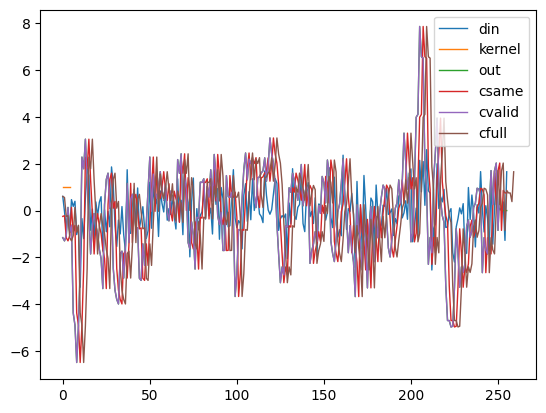

In [34]:
din1 = np.random.randn(256)
kernel = np.ones(5)
out = np.zeros_like(din1)
esam.convolve_with_kernel(din1, kernel, out)
csame = np.convolve(din1, kernel, mode='same')
cvalid = np.convolve(din1, kernel, mode='valid')
cfull = np.convolve(din1, kernel, mode='full')

plot(din1, label='din')
plot(kernel, label='kernel')
plot(out, label='out')
plot(csame, label='csame')
plot(cvalid, label='cvalid')
plot(cfull, label='cfull')
#np.testing.assert_allclose(out, convolved)
legend()

In [35]:
%timeit np.convolve(din1, kernel, mode='same')

843 ns ± 17.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [36]:
%timeit     esam.convolve_with_kernel(din1, kernel, out)


886 ns ± 11.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [37]:
tree.count_all_operations(0, 16)

[99, 53, 89, 231, 428, 320, 365, 366, 368]

In [38]:
sum(tree.count_all_operations(0, 16))

np.int64(2319)

In [39]:
nops = sum(tree.count_all_operations(0, 16))
time = nops/1e9 # assume 1GHz clock
block_time_single = time*256
noutputs = 435*288/16
total_time = block_time_single*noutputs
print(f'1 output requires {nops} operations taking {time}x256={block_time_single} seconds for a total of {total_time} seconds for {noutputs} outputs')

1 output requires 2319 operations taking 2.319e-06x256=0.000593664 seconds for a total of 4.64838912 seconds for 7830.0 outputs


In [40]:
# Need to make 
nout_per_sec = 435*288/16*256/(1.7e-3*256)
nops_per_sec = 1e9
nops_per_output = nops_per_sec / nout_per_sec
print(f'Nout per second is {nout_per_sec} Max nops per output is {nops_per_output} for 435x288/16 = {435*288/16} outputs')


Nout per second is 4605882.352941177 Max nops per output is 217.11366538952743 for 435x288/16 = 7830.0 outputs
